In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vladiknt/yandex-stock-price-1-day-period/yandex_1day.csv
/kaggle/input/datasets/usamabuttar/world-happiness-report-2005-present/World Happiness Report.csv


In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Загрузка данных
df1 = pd.read_csv(r"/kaggle/input/datasets/usamabuttar/world-happiness-report-2005-present/World Happiness Report.csv")
df2 = pd.read_csv(r"/kaggle/input/datasets/vladiknt/yandex-stock-price-1-day-period/yandex_1day.csv")

print("Данные загружены")
print(f"df1 shape: {df1.shape}")
print(f"df2 shape: {df2.shape}")

Данные загружены
df1 shape: (2199, 13)
df2 shape: (2356, 7)


In [4]:

df1 = df1[df1["Country Name"] == "Russia"]

df2['date'] = pd.to_datetime(df2['date'])
df2['year'] = df2['date'].dt.year
first_days = df2.sort_values('date').groupby('year').first().reset_index()

merged = first_days.merge(df1, left_on='year', right_on='Year', how='inner')

print(f"После объединения: {merged.shape}")
print("Годы в данных:", sorted(merged['year'].unique()))

После объединения: (9, 21)
Годы в данных: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


                            OLS Regression Results                            
Dep. Variable:                   open   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     17.43
Date:                Sun, 05 Apr 2026   Prob (F-statistic):            0.00924
Time:                        13:35:51   Log-Likelihood:                -58.002
No. Observations:                   8   AIC:                             124.0
Df Residuals:                       4   BIC:                             124.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

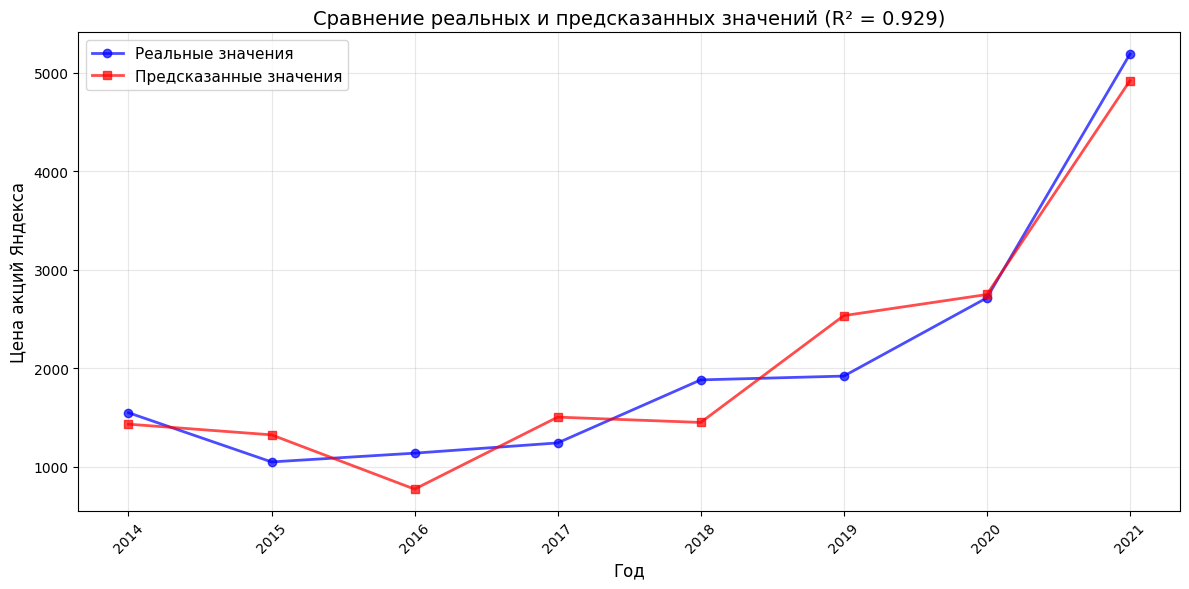

In [5]:
feature_cols = ['Log GDP Per Capita', 
                'Healthy Life Expectancy At Birth', 
                'Confidence In National Government']

merged_clean = merged.dropna(subset=feature_cols + ['open'])
X = merged_clean[feature_cols]
y = merged_clean['open']
years = merged_clean['year']

X2 = sm.add_constant(X)
model2 = sm.OLS(y, X2).fit()

print(model2.summary())

y_pred = model2.predict(X2)

plt.figure(figsize=(12, 6))

plt.plot(years, y, 'b-o', label='Реальные значения', linewidth=2, markersize=6, alpha=0.7)
plt.plot(years, y_pred, 'r-s', label='Предсказанные значения', linewidth=2, markersize=6, alpha=0.7)

plt.xlabel('Год', fontsize=12)
plt.ylabel('Цена акций Яндекса', fontsize=12)
plt.title(f'Сравнение реальных и предсказанных значений (R² = {model2.rsquared:.3f})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(years, rotation=45)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                   open   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     17.43
Date:                Sun, 05 Apr 2026   Prob (F-statistic):            0.00924
Time:                        13:35:52   Log-Likelihood:                -58.002
No. Observations:                   8   AIC:                             124.0
Df Residuals:                       4   BIC:                             124.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

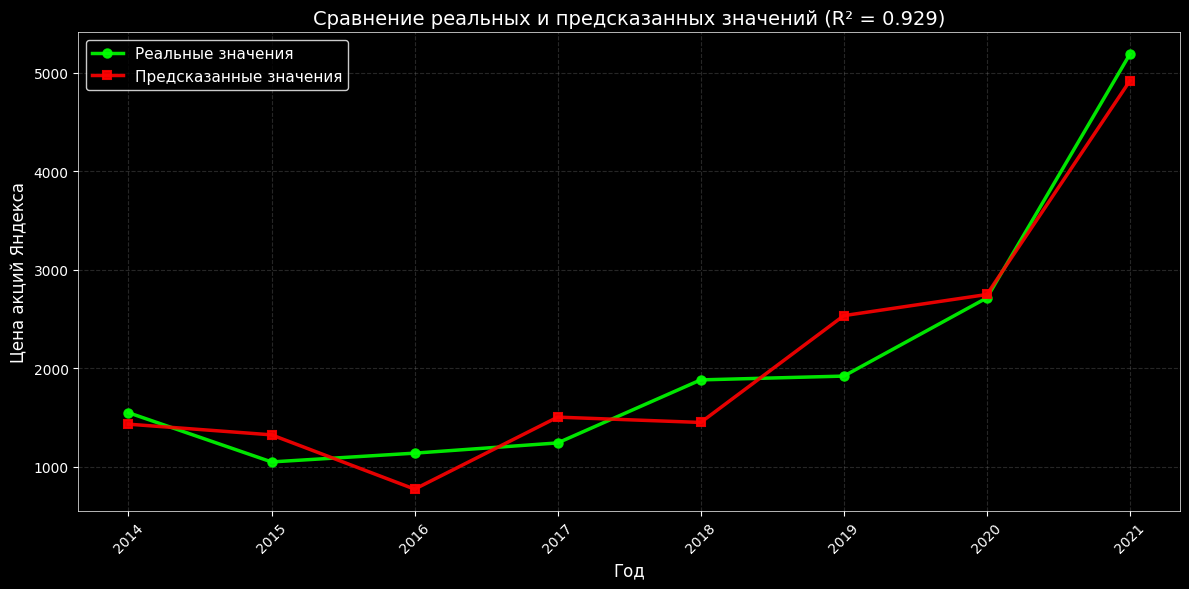

In [6]:

feature_cols = ['Log GDP Per Capita', 
                'Healthy Life Expectancy At Birth', 
                'Confidence In National Government']


merged_clean = merged.dropna(subset=feature_cols + ['open'])
X = merged_clean[feature_cols]
y = merged_clean['open']
years = merged_clean['year']


X2 = sm.add_constant(X)
model2 = sm.OLS(y, X2).fit()

print(model2.summary())


y_pred = model2.predict(X2)

plt.style.use('dark_background')
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')


plt.plot(years, y, color='#00FF00', marker='o', label='Реальные значения', 
         linewidth=2.5, markersize=6, alpha=0.9, 
         markerfacecolor='#00FF00', markeredgecolor='#00FF00', 
         markeredgewidth=1.5)

plt.plot(years, y_pred, color='#FF0000', marker='s', label='Предсказанные значения', 
         linewidth=2.5, markersize=6, alpha=0.9,
         markerfacecolor='#FF0000', markeredgecolor='#FF0000',
         markeredgewidth=1.5)

plt.xlabel('Год', fontsize=12, color='white')
plt.ylabel('Цена акций Яндекса', fontsize=12, color='white')
plt.title(f'Сравнение реальных и предсказанных значений (R² = {model2.rsquared:.3f})', 
          fontsize=14, color='white')

legend = plt.legend(fontsize=11, facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.grid(True, alpha=0.3, color='gray', linestyle='--')

plt.xticks(years, rotation=45, color='white')
plt.yticks(color='white')

for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(0.5)


plt.savefig('yandex_stocks_plot.png', dpi=300, bbox_inches='tight', facecolor='black')

print("График сохранен как 'yandex_stocks_plot.png'")

plt.tight_layout()
plt.show()